In [49]:
import os
from pathlib import Path
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt

In [50]:
# ---- paths ----
DATA_ROOT = Path("/cluster/courses/cil/monocular-depth-estimation/train")

# ---- config ----
IMG_SIZE = 560
MAX_SAMPLES = 5000
DEVICE = "cpu"

print("Using device:", DEVICE)

Using device: cpu


In [51]:
!du -h $DATA_ROOT

36G	/cluster/courses/cil/monocular-depth-estimation/train


In [52]:
!ls $DATA_ROOT | head -n 6

train_000000_depth.npy
train_000000_rgb.png
train_000001_depth.npy
train_000001_rgb.png
train_000002_depth.npy
train_000002_rgb.png
ls: write error: Broken pipe


In [53]:
class SimpleDepthDataset(Dataset):
    def __init__(self, root: Path, img_size=128, max_samples=None):
        self.root = Path(root)
        self.img_size = img_size
        
        self.rgb_files = sorted(self.root.glob("*_rgb.png"))
        if max_samples is not None:
            self.rgb_files = self.rgb_files[:max_samples]
        
        assert len(self.rgb_files) > 0, f"No *_rgb.png files found in {self.root}"

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):
        rgb_path = self.rgb_files[idx]
        depth_path = Path(str(rgb_path).replace("_rgb.png", "_depth.npy"))
        
        # load rgb
        rgb = np.array(Image.open(rgb_path).convert("RGB"), dtype=np.float32) / 255.0
        
        # load depth
        depth = np.load(depth_path).astype(np.float32)
        
        # resize rgb
        rgb_t = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0)   # [1,3,H,W]
        rgb_t = F.interpolate(rgb_t, size=(self.img_size, self.img_size), mode="bilinear", align_corners=False)
        rgb_t = rgb_t.squeeze(0)  # [3,H,W]
        
        # resize depth
        depth_t = torch.from_numpy(depth).unsqueeze(0).unsqueeze(0)   # [1,1,H,W]
        depth_t = F.interpolate(depth_t, size=(self.img_size, self.img_size), mode="nearest")
        depth_t = depth_t.squeeze(0)  # [1,H,W]
        
        # valid mask: depth > 0
        valid_mask = (depth_t > 0).float()
        
        return {
            "image": rgb_t,
            "depth": depth_t,
            "mask": valid_mask,
            "name": rgb_path.name
        }

In [54]:
small_dataset = SimpleDepthDataset(DATA_ROOT, img_size=IMG_SIZE, max_samples=MAX_SAMPLES)

print(f"Viz samples: {len(small_dataset)}")

Viz samples: 5000


In [55]:
import matplotlib.gridspec as gridspec

def visualize_random_batch(dataset, batch_size=4, figsize_per_item=(4, 8)):
    n = batch_size
    indices = random.sample(range(len(dataset)), n)

    fig_w = figsize_per_item[0] * n
    fig_h = figsize_per_item[1]
    fig = plt.figure(figsize=(fig_w, fig_h))

    gs = gridspec.GridSpec(2, n, figure=fig, hspace=0.05, wspace=0.15)

    for col, idx in enumerate(indices):
        sample = dataset[idx]

        # Plot rgb
        rgb = sample["image"].permute(1, 2, 0).numpy()
        ax_rgb = fig.add_subplot(gs[0, col])
        ax_rgb.imshow(rgb)
        ax_rgb.axis("off")
        if col == 0:
            ax_rgb.set_ylabel("RGB", fontsize=9, labelpad=4)
        ax_rgb.set_title(sample["name"], fontsize=7, pad=3)

        # Plot depth
        depth = sample["depth"].squeeze(0).numpy()
        mask = sample["mask"].squeeze(0).numpy()

        depth_vis = depth.copy()
        depth_vis[mask == 0] = np.nan

        ax_depth = fig.add_subplot(gs[1, col])
        im = ax_depth.imshow(depth_vis, cmap="viridis")
        ax_depth.axis("off")
        if col == 0:
            ax_depth.set_ylabel("Depth", fontsize=9, labelpad=4)
        plt.colorbar(im, ax=ax_depth, fraction=0.046, pad=0.04)

    fig.suptitle(
        f"Random batch — {n} samples  (indices {indices})",
        fontsize=10, y=1.01
    )
    plt.show()

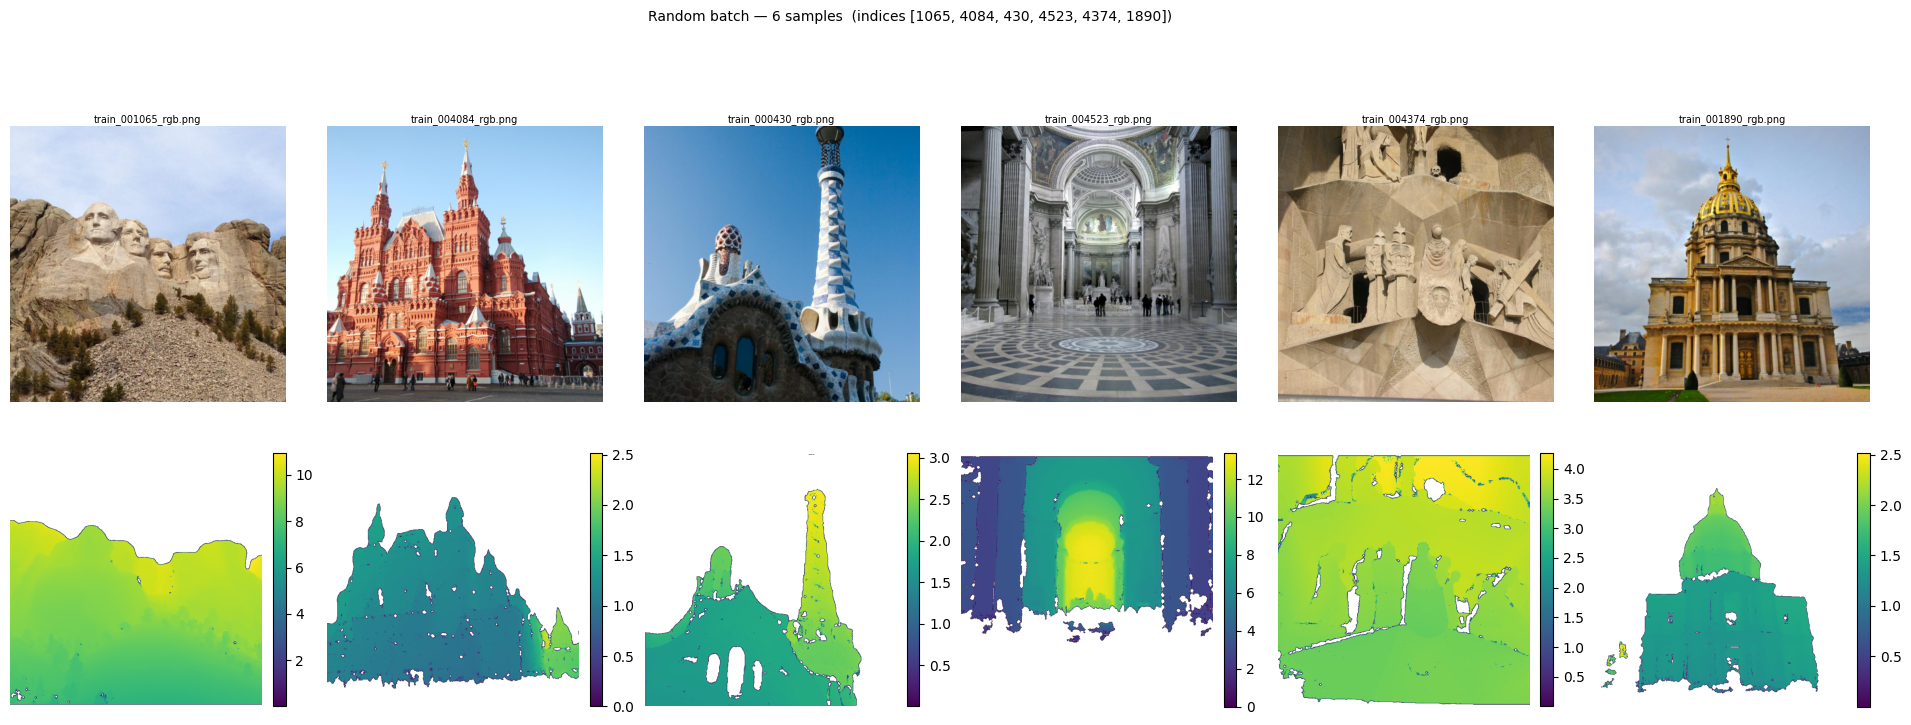

In [56]:
# Run once to see a random batch
visualize_random_batch(small_dataset, batch_size=6)